In [ ]:
import pandas as pd
from scipy.stats import ks_2samp
import numpy as np

from gsm_benchmarker.results_analyser.prompt_result import MultiPromptResult

from results_notebook_setup import ALPHA, load_results, original_model_order, OUTPUTS_FOLDER, significant_models_path


In [ ]:
N_BOOT = 2000
results_loader = load_results(n_boot=N_BOOT)
full_results = results_loader.full_results

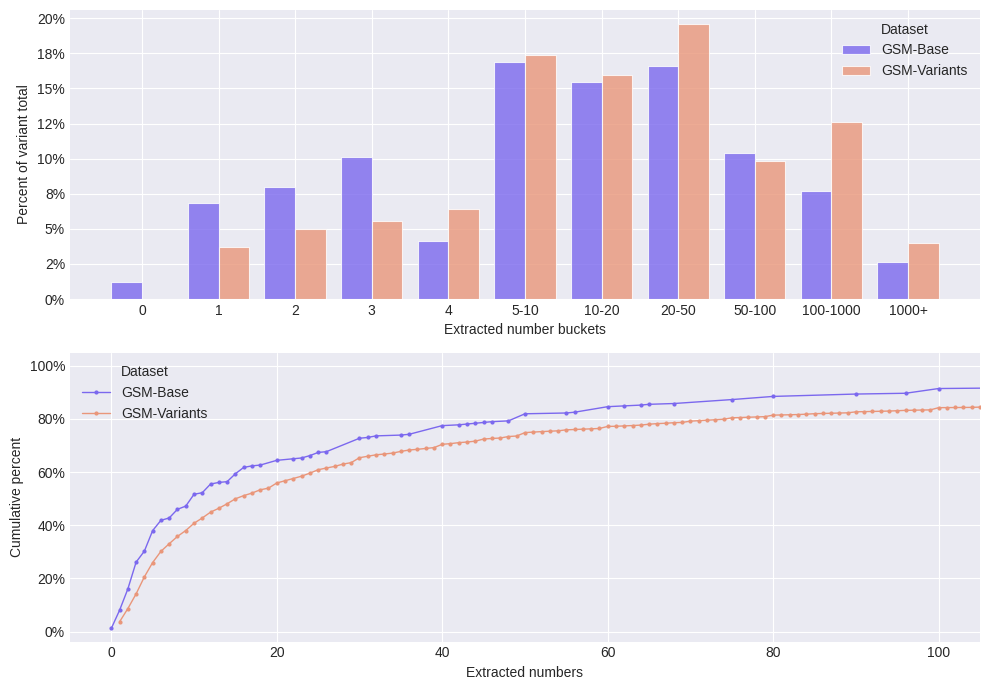

In [3]:
_ = results_loader.gsm.mres.plot_number_counts(save_prefix=OUTPUTS_FOLDER)

### Evaluating number distribution shift in GSM-Variants w.r.t. GSM-Base

In [4]:
number_counts = results_loader.gsm.mres.get_number_counts()[0]
numeric_index = pd.to_numeric(number_counts.index)

gsm8k_samples = np.repeat(numeric_index, number_counts['GSM-Base'].values)
main_samples = np.repeat(numeric_index, number_counts['GSM-Variants'].values)

ks_stat, p_value = ks_2samp(gsm8k_samples, main_samples)

print(f"K-S Statistic: {ks_stat:.4f}")
print(f"P-value: {p_value:.4e}")

K-S Statistic: 0.1201
P-value: 1.2788e-04


## Question 1
Are the accuracy drops reported in the GSM-Symbolic paper actually significant?

Evaluating significance of accuracy change on 'main' variant vs 'GSM8K' variant with GSM-Symbolic prompt.

[<Figure size 1000x550 with 1 Axes>, <Figure size 1000x550 with 2 Axes>]

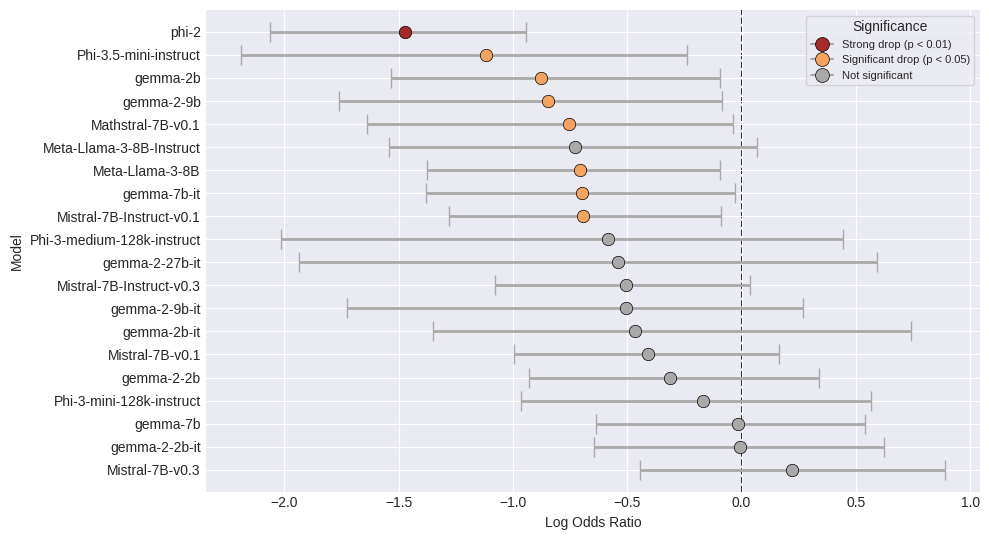

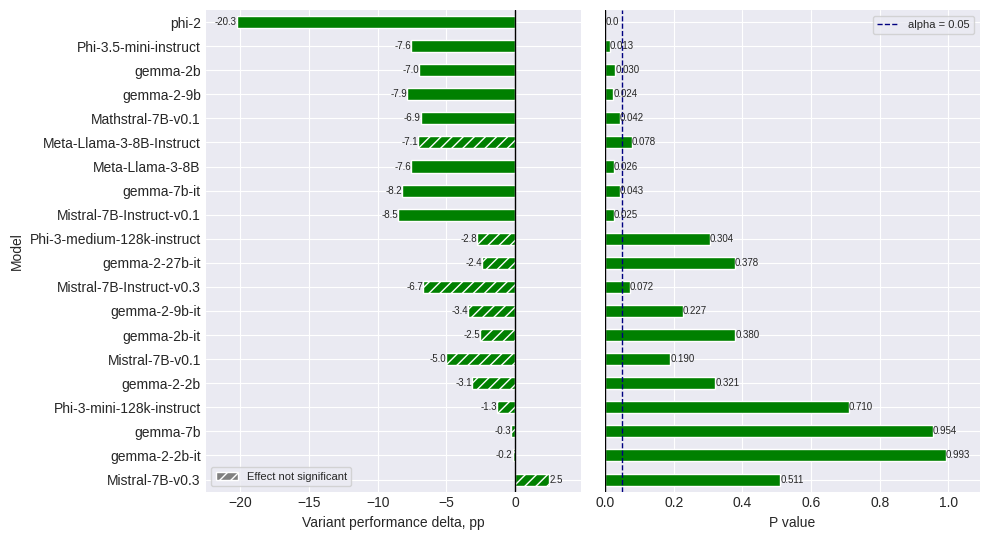

In [5]:
results_loader.gsm.plot_glmm1()

In [6]:
results_loader.gsm.glmm1_results

,,boot_ci_upper_log,boot_ci_lower_log,boot_se_log,boot_mean_log,boot_median_log,boot_p_value,boot_n_requested,boot_n_failed,boot_n_nonconverged,boot_n_singular,...,wald_ranef_variance,wald_ranef_sd,wald_significant,wald_ci_width_log,agreement,width_ratio_log,bias_log,GSM8K_acc,main_acc,acc_diff
model,metric,,,,,,,,,,,,,,,,,,,,,
Mathstral-7B-v0.1,is_variant,-0.037108,-1.636772,0.411317,-0.770811,-0.753924,0.042021,2000.0,0.0,1.0,0.0,...,6.464563,2.542551,True,1.348435,True,1.186312,-0.012248,82.0,75.12,-6.88
Meta-Llama-3-8B,is_variant,-0.096309,-1.374645,0.319634,-0.708519,-0.705076,0.026000,2000.0,0.0,0.0,0.0,...,11.253625,3.354642,True,1.183447,True,1.080180,-0.009005,55.0,47.44,-7.56
Meta-Llama-3-8B-Instruct,is_variant,0.065518,-1.541850,0.401929,-0.728287,-0.729621,0.078078,2000.0,0.0,2.0,0.0,...,9.954473,3.155071,True,1.282309,False,1.253495,-0.007370,77.0,69.92,-7.08
Mistral-7B-Instruct-v0.1,is_variant,-0.089163,-1.278804,0.300793,-0.692053,-0.694678,0.025025,2000.0,0.0,2.0,0.0,...,5.064026,2.250339,True,1.069828,True,1.111993,-0.006858,36.0,27.46,-8.54
Mistral-7B-Instruct-v0.3,is_variant,0.036228,-1.078176,0.283162,-0.506964,-0.506042,0.072000,2000.0,0.0,0.0,0.0,...,6.984646,2.642848,False,1.070019,True,1.041480,-0.005621,52.0,45.32,-6.68
Mistral-7B-v0.1,is_variant,0.162101,-0.993912,0.303007,-0.405993,-0.407568,0.189664,2000.0,0.0,7.0,0.0,...,6.802050,2.608074,False,1.103661,True,1.047435,-0.000936,38.0,33.00,-5.00
Mistral-7B-v0.3,is_variant,0.888871,-0.444801,0.334739,0.220823,0.219352,0.510511,2000.0,0.0,2.0,0.0,...,7.084966,2.661760,False,1.127702,True,1.182646,0.012421,33.0,35.50,2.50
Phi-3-medium-128k-instruct,is_variant,0.444094,-2.014073,0.636637,-0.643214,-0.585985,0.304082,2000.0,0.0,40.0,0.0,...,9.503760,3.082817,False,1.889368,True,1.301052,-0.020501,91.0,88.22,-2.78
Phi-3-mini-128k-instruct,is_variant,0.564985,-0.965581,0.385702,-0.162731,-0.167100,0.709839,2000.0,0.0,8.0,0.0,...,8.946310,2.991038,False,1.377187,True,1.111371,-0.012353,80.0,78.70,-1.30


In [7]:
results_loader.gsm.glmm1_results_to_latex(model_order=original_model_order)

\begin{table}[H]
\caption{Results of GSM prompt The $\ddagger$ symbol marks cases where significance estimated with Wald method did not match the bootstrap estimate.}
\label{tab:GSM-results}
\begin{tabular}{lccccc}
\toprule
Model & GSM-Base acc & GSM-Variants acc & $\Delta$ Acc & P value & Corrected P value \\
\midrule
gemma-2b & 19.0 & 12.0 & -6.96 & \textbf{0.030} & 0.443 \\
gemma-2b-it & 10.0 & 7.5 & -2.52 & 0.380 & 1.000 \\
gemma-7b & 48.0 & 47.7 & -0.30 & 0.954 & 1.000 \\
gemma-7b-it & 31.0 & 22.8 & -8.22 & \textbf{0.043} & 0.588 \\
gemma-2-2b & 24.0 & 20.9 & -3.12 & 0.321 $\ddagger$ & 1.000 \\
gemma-2-2b-it & 42.0 & 41.8 & -0.18 & 0.993 & 1.000 \\
gemma-2-9b & 69.0 & 61.1 & -7.88 & \textbf{0.024} & 0.432 \\
gemma-2-9b-it & 86.0 & 82.6 & -3.40 & 0.227 & 1.000 \\
gemma-2-27b-it & 90.0 & 87.6 & -2.40 & 0.378 & 1.000 \\
phi-2 & 60.0 & 39.7 & -20.26 & \textbf{< 0.001} & \textbf{< 0.001} \\
Phi-3-mini-128k-instruct & 80.0 & 78.7 & -1.30 & 0.710 & 1.000 \\
Phi-3-medium-128k-instruct & 9

In [8]:
results_loader.gsm.mres.bootstrap_glmm1

,,boot_ci_upper_log,boot_ci_lower_log,boot_se_log,boot_mean_log,boot_median_log,boot_p_value,boot_n_requested,boot_n_failed,boot_n_nonconverged,boot_n_singular,...,wald_ranef_variance,wald_ranef_sd,wald_significant,wald_ci_width_log,agreement,width_ratio_log,bias_log,GSM8K_acc,main_acc,acc_diff
model,metric,,,,,,,,,,,,,,,,,,,,,
Mathstral-7B-v0.1,is_variant,-0.037108,-1.636772,0.411317,-0.770811,-0.753924,0.042021,2000.0,0.0,1.0,0.0,...,6.464563,2.542551,True,1.348435,True,1.186312,-0.012248,82.0,75.12,-6.88
Meta-Llama-3-8B,is_variant,-0.096309,-1.374645,0.319634,-0.708519,-0.705076,0.026000,2000.0,0.0,0.0,0.0,...,11.253625,3.354642,True,1.183447,True,1.080180,-0.009005,55.0,47.44,-7.56
Meta-Llama-3-8B-Instruct,is_variant,0.065518,-1.541850,0.401929,-0.728287,-0.729621,0.078078,2000.0,0.0,2.0,0.0,...,9.954473,3.155071,True,1.282309,False,1.253495,-0.007370,77.0,69.92,-7.08
Mistral-7B-Instruct-v0.1,is_variant,-0.089163,-1.278804,0.300793,-0.692053,-0.694678,0.025025,2000.0,0.0,2.0,0.0,...,5.064026,2.250339,True,1.069828,True,1.111993,-0.006858,36.0,27.46,-8.54
Mistral-7B-Instruct-v0.3,is_variant,0.036228,-1.078176,0.283162,-0.506964,-0.506042,0.072000,2000.0,0.0,0.0,0.0,...,6.984646,2.642848,False,1.070019,True,1.041480,-0.005621,52.0,45.32,-6.68
Mistral-7B-v0.1,is_variant,0.162101,-0.993912,0.303007,-0.405993,-0.407568,0.189664,2000.0,0.0,7.0,0.0,...,6.802050,2.608074,False,1.103661,True,1.047435,-0.000936,38.0,33.00,-5.00
Mistral-7B-v0.3,is_variant,0.888871,-0.444801,0.334739,0.220823,0.219352,0.510511,2000.0,0.0,2.0,0.0,...,7.084966,2.661760,False,1.127702,True,1.182646,0.012421,33.0,35.50,2.50
Phi-3-medium-128k-instruct,is_variant,0.444094,-2.014073,0.636637,-0.643214,-0.585985,0.304082,2000.0,0.0,40.0,0.0,...,9.503760,3.082817,False,1.889368,True,1.301052,-0.020501,91.0,88.22,-2.78
Phi-3-mini-128k-instruct,is_variant,0.564985,-0.965581,0.385702,-0.162731,-0.167100,0.709839,2000.0,0.0,8.0,0.0,...,8.946310,2.991038,False,1.377187,True,1.111371,-0.012353,80.0,78.70,-1.30


In [9]:
significant_models = results_loader.gsm.get_significant_models(alpha=ALPHA, drop_only=True)
significant_models

['phi-2',
 'Phi-3.5-mini-instruct',
 'gemma-2b',
 'gemma-2-9b',
 'Mathstral-7B-v0.1',
 'Meta-Llama-3-8B',
 'gemma-7b-it',
 'Mistral-7B-Instruct-v0.1']

In [10]:
len(significant_models)

8

In [11]:
for key, res in full_results.items():
    if key != 'GSM':
        res.models = significant_models

with open(significant_models_path, 'w') as f:
    f.writelines([f"{m}\n" for m in significant_models])


## Question 2
Do alternative prompt formats remove the variant dependency?

[<Figure size 1000x310 with 1 Axes>, <Figure size 1000x310 with 2 Axes>]

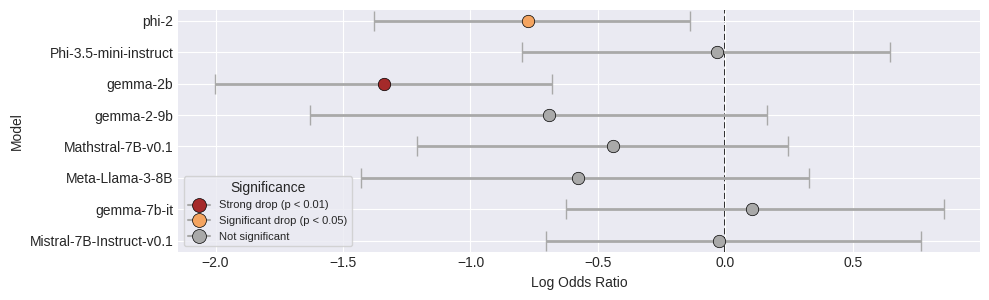

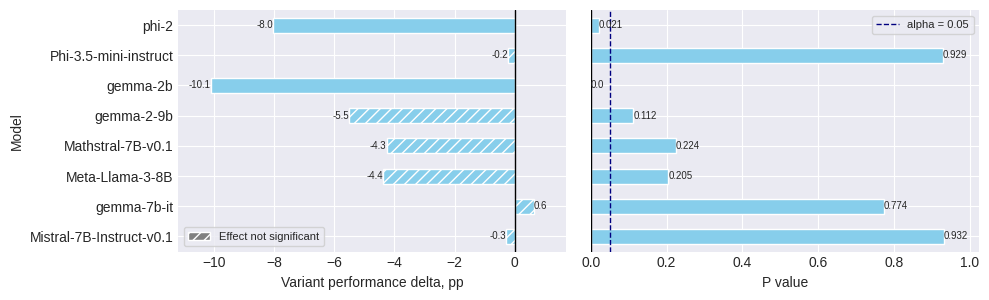

In [12]:
results_loader.nonformal.plot_glmm1(model_order=significant_models[::-1])

In [13]:
results_loader.nonformal.glmm1_results_to_latex(model_order=significant_models)

\begin{table}[H]
\caption{Results of Simple NL prompt}
\label{tab:NL-simple-results}
\begin{tabular}{lccccc}
\toprule
Model & GSM-Base acc & GSM-Variants acc & $\Delta$ Acc & P value & Corrected P value \\
\midrule
phi-2 & 45.0 & 37.0 & -8.04 & \textbf{0.021} & 0.147 \\
Phi-3.5-mini-instruct & 73.0 & 72.8 & -0.22 & 0.929 & 1.000 \\
gemma-2b & 21.0 & 10.9 & -10.12 & \textbf{< 0.001} & \textbf{< 0.001} \\
gemma-2-9b & 67.0 & 61.5 & -5.52 & 0.112 & 0.673 \\
Mathstral-7B-v0.1 & 73.0 & 68.7 & -4.26 & 0.224 & 1.000 \\
Meta-Llama-3-8B & 21.0 & 16.6 & -4.38 & 0.205 & 1.000 \\
gemma-7b-it & 24.0 & 24.6 & 0.64 & 0.774 & 1.000 \\
Mistral-7B-Instruct-v0.1 & 26.0 & 25.7 & -0.30 & 0.932 & 1.000 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[H]
\caption{Additional statistics for results of Simple NL prompt.}
\label{tab:NL-simple-stats}
\begin{tabular}{lcccc}
\toprule
Model & Odds ratio & 95\% CI & Rand. eff. variance $\pm$ std. dev. & N estimates \\
\midrule
phi-2 & 0.46 & [0.25, 0.87] & 13.

[<Figure size 1000x310 with 1 Axes>, <Figure size 1000x310 with 2 Axes>]

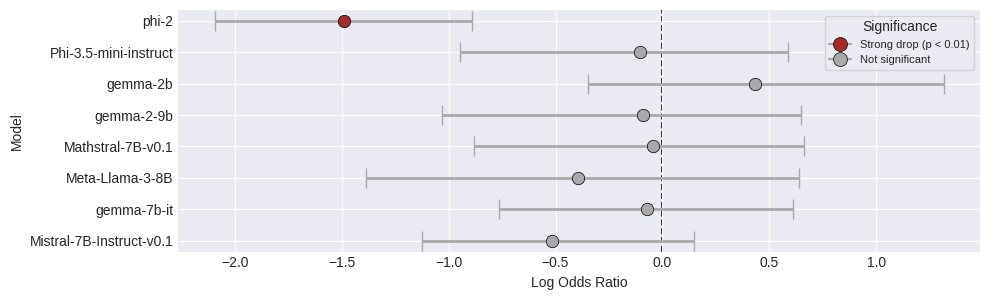

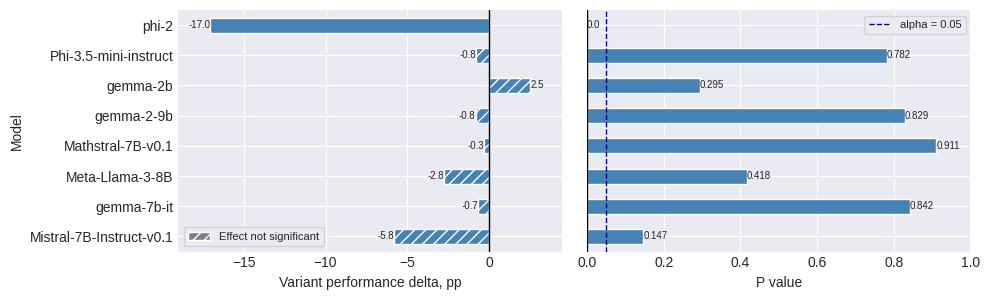

In [14]:
results_loader.formal.plot_glmm1(model_order=significant_models[::-1])

In [15]:
results_loader.formal.glmm1_results_to_latex(model_order=significant_models)

\begin{table}[H]
\caption{Results of Structured NL prompt}
\label{tab:NL-structured-results}
\begin{tabular}{lccccc}
\toprule
Model & GSM-Base acc & GSM-Variants acc & $\Delta$ Acc & P value & Corrected P value \\
\midrule
phi-2 & 63.0 & 46.0 & -17.04 & \textbf{< 0.001} & \textbf{< 0.001} \\
Phi-3.5-mini-instruct & 77.0 & 76.2 & -0.80 & 0.782 & 1.000 \\
gemma-2b & 12.0 & 14.5 & 2.50 & 0.295 & 1.000 \\
gemma-2-9b & 72.0 & 71.2 & -0.84 & 0.829 & 1.000 \\
Mathstral-7B-v0.1 & 78.0 & 77.7 & -0.34 & 0.911 & 1.000 \\
Meta-Llama-3-8B & 16.0 & 13.2 & -2.78 & 0.418 & 1.000 \\
gemma-7b-it & 29.0 & 28.3 & -0.68 & 0.842 & 1.000 \\
Mistral-7B-Instruct-v0.1 & 35.0 & 29.2 & -5.82 & 0.147 & 1.000 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[H]
\caption{Additional statistics for results of Structured NL prompt.}
\label{tab:NL-structured-stats}
\begin{tabular}{lcccc}
\toprule
Model & Odds ratio & 95\% CI & Rand. eff. variance $\pm$ std. dev. & N estimates \\
\midrule
phi-2 & 0.23 & [0.12, 0.41

[<Figure size 1000x310 with 1 Axes>, <Figure size 1000x310 with 2 Axes>]

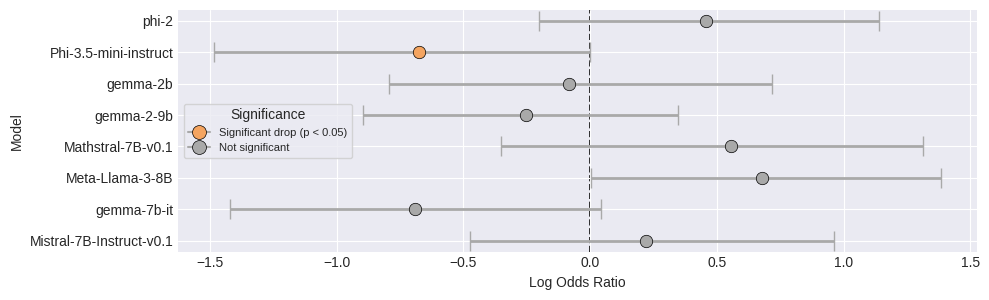

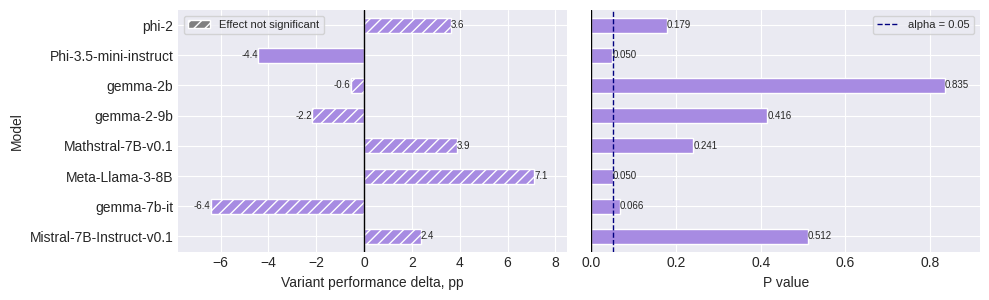

In [16]:
results_loader.short_code.plot_glmm1(model_order=significant_models[::-1])

In [17]:
results_loader.short_code.glmm1_results_to_latex(model_order=significant_models)

\begin{table}[H]
\caption{Results of Simple code-output prompt The $\ddagger$ symbol marks cases where significance estimated with Wald method did not match the bootstrap estimate.}
\label{tab:code-simple-results}
\begin{tabular}{lccccc}
\toprule
Model & GSM-Base acc & GSM-Variants acc & $\Delta$ Acc & P value & Corrected P value \\
\midrule
phi-2 & 63.0 & 66.6 & 3.64 & 0.179 & 0.894 \\
Phi-3.5-mini-instruct & 81.0 & 76.6 & -4.42 & \textbf{0.050} $\ddagger$ & 0.396 \\
gemma-2b & 14.0 & 13.4 & -0.56 & 0.835 & 1.000 \\
gemma-2-9b & 68.0 & 65.8 & -2.18 & 0.416 & 1.000 \\
Mathstral-7B-v0.1 & 75.0 & 78.9 & 3.88 & 0.241 & 0.963 \\
Meta-Llama-3-8B & 48.0 & 55.1 & 7.12 & 0.050 $\ddagger$ & 0.396 \\
gemma-7b-it & 47.0 & 40.6 & -6.42 & 0.066 $\ddagger$ & 0.399 \\
Mistral-7B-Instruct-v0.1 & 41.0 & 43.4 & 2.36 & 0.512 & 1.000 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[H]
\caption{Additional statistics for results of Simple code-output prompt.}
\label{tab:code-simple-stats}
\begin{tabu

[<Figure size 1000x310 with 1 Axes>, <Figure size 1000x310 with 2 Axes>]

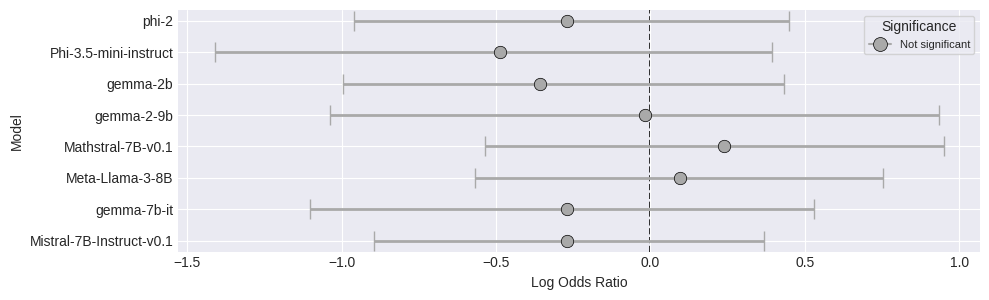

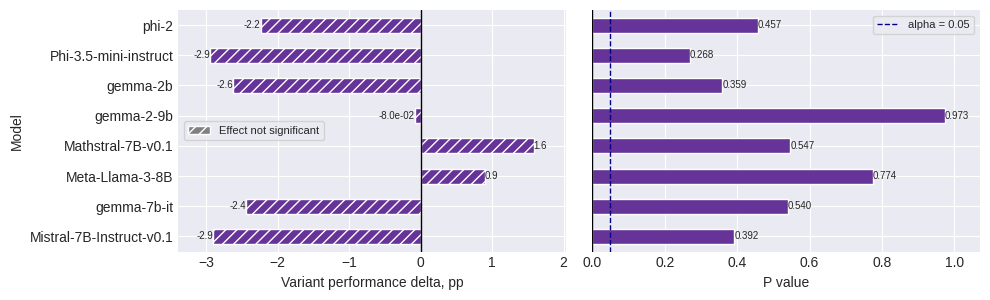

In [18]:
results_loader.long_code.plot_glmm1(model_order=significant_models[::-1])

In [19]:
results_loader.long_code.glmm1_results_to_latex(model_order=significant_models)

\begin{table}[H]
\caption{Results of Structured code-output prompt}
\label{tab:code-structured-results}
\begin{tabular}{lccccc}
\toprule
Model & GSM-Base acc & GSM-Variants acc & $\Delta$ Acc & P value & Corrected P value \\
\midrule
phi-2 & 66.0 & 63.8 & -2.24 & 0.457 & 1.000 \\
Phi-3.5-mini-instruct & 83.0 & 80.1 & -2.94 & 0.268 & 1.000 \\
gemma-2b & 16.0 & 13.4 & -2.62 & 0.359 & 1.000 \\
gemma-2-9b & 68.0 & 67.9 & -0.08 & 0.973 & 1.000 \\
Mathstral-7B-v0.1 & 78.0 & 79.6 & 1.58 & 0.547 & 1.000 \\
Meta-Llama-3-8B & 49.0 & 49.9 & 0.90 & 0.774 & 1.000 \\
gemma-7b-it & 43.0 & 40.6 & -2.44 & 0.540 & 1.000 \\
Mistral-7B-Instruct-v0.1 & 47.0 & 44.1 & -2.90 & 0.392 & 1.000 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[H]
\caption{Additional statistics for results of Structured code-output prompt.}
\label{tab:code-structured-stats}
\begin{tabular}{lcccc}
\toprule
Model & Odds ratio & 95\% CI & Rand. eff. variance $\pm$ std. dev. & N estimates \\
\midrule
phi-2 & 0.76 & [0.38, 1.57] 

### Summary of all prompts and models


In [20]:
all_prompts_result = MultiPromptResult(full_results, save_prefix=OUTPUTS_FOLDER)
all_prompts_result.summary

model                                          Mathstral-7B-v0.1  \
prompt          quantity                                           
GSM             GSM8K_acc                                   82.0   
                main_acc                                   75.12   
                acc_diff                                   -6.88   
                variant_effect_log_or                  -0.753924   
                variant_effect_or                       0.470517   
...                                                          ...   
code-structured nec_variant_effect_log_or               0.195681   
                nec_variant_effect_or                   1.216138   
                nec_variant_effect_p_value              0.636837   
                nec_variant_effect_significant             False   
                nec_variant_effect_agreement                True   

model                                          Meta-Llama-3-8B  \
prompt          quantity                                         
GSM             GSM8K_acc                                 55.0   
                main_acc                                 47.44   
                acc_diff                                 -7.56   
                variant_effect_log_or                -0.705076   
                variant_effect_or                     0.494071   
...                                                        ...   
code-structured nec_variant_effect_log_or             0.127247   
                nec_variant_effect_or                 1.135698   
                nec_variant_effect_p_value               0.699   
                nec_variant_effect_significant           False   
                nec_variant_effect_agreement              True   

model                                          Meta-Llama-3-8B-Instruct  \
prompt          quantity                                                  
GSM             GSM8K_acc                                          77.0   
                main_acc                                          69.92   
                acc_diff                                          -7.08   
                variant_effect_log_or                         -0.729621   
                variant_effect_or                              0.482092   
...                                                                 ...   
code-structured nec_variant_effect_log_or                           NaN   
                nec_variant_effect_or                               NaN   
                nec_variant_effect_p_value                          NaN   
                nec_variant_effect_significant                      NaN   
                nec_variant_effect_agreement                        NaN   

model                                          Mistral-7B-Instruct-v0.1  \
prompt          quantity                                                  
GSM             GSM8K_acc                                          36.0   
                main_acc                                          27.46   
                acc_diff                                          -8.54   
                variant_effect_log_or                         -0.694678   
                variant_effect_or                              0.499235   
...                                                                 ...   
code-structured nec_variant_effect_log_or                     -0.320067   
                nec_variant_effect_or                            0.7261   
                nec_variant_effect_p_value                        0.356   
                nec_variant_effect_significant                    False   
                nec_variant_effect_agreement                       True   

model                                          Mistral-7B-Instruct-v0.3  \
prompt          quantity                                                  
GSM             GSM8K_acc                                          52.0   
                main_acc                                          45.32   
    

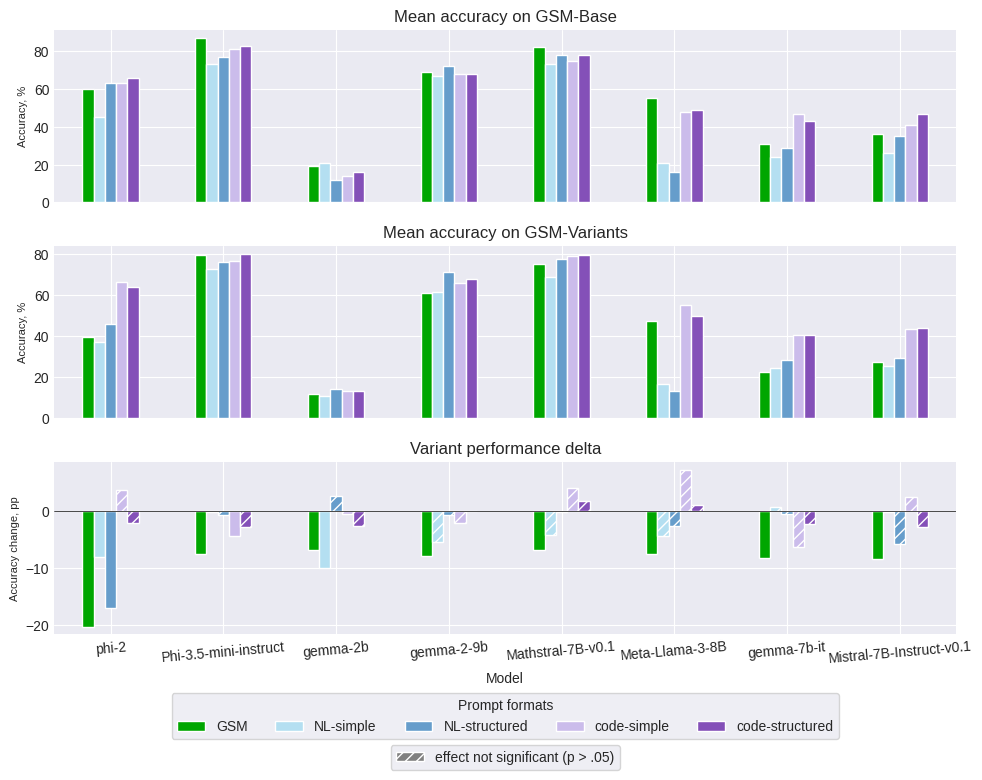

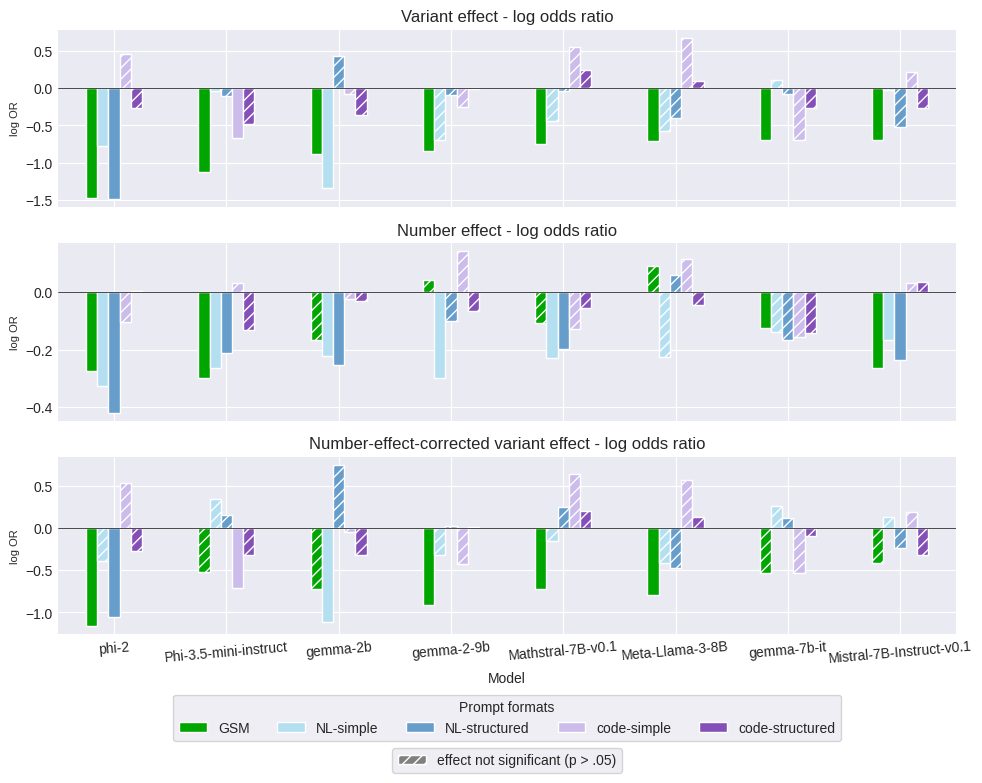

In [21]:
fig = all_prompts_result.plot_prompt_comparison(models=significant_models, add_bar_labels=False, x_labels_rotation=5, figsize=(10, 8), bottom=0.2, second_legend_offset=0.4, first_legend_offset=0.1)

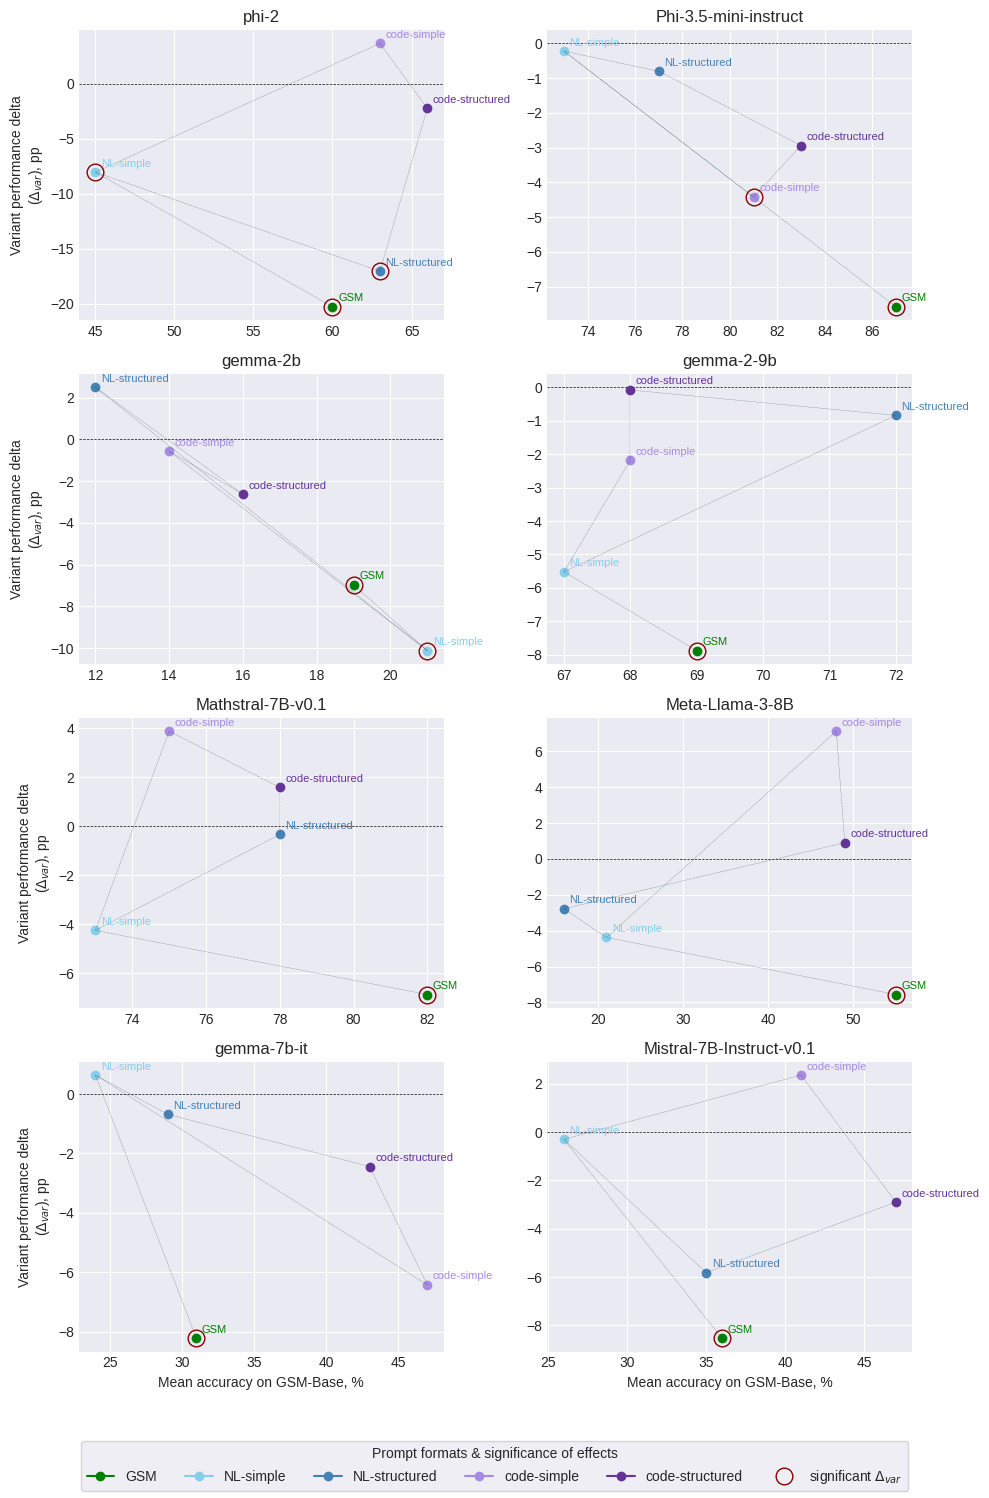

In [22]:
fig = all_prompts_result.plot_prompt_acc_evolution(models=significant_models, n_cols=2, sharex=False, sharey=False, equal_aspect=False, figsize=(10, 15), bottom_margin=.06)


### Number effect tables

In [23]:
# number effect - GLMM results
all_prompts_result.glmm2_to_latex("number_effect", models=significant_models)

\begin{table}[H]
\caption{Odds ratios and significance of the number effect across models and prompt formats. Formatted as: Odds Ratio \\ Raw $p$ / Corrected $p$. The $\ddagger$ symbol marks cases where Wald-derived statistical significance status does not match the bootstrap one.}
\label{tab:glmm2_number_effect_odds}
\begin{tabular}{lccccc}
\toprule
prompt & GSM & NL-simple & NL-structured & code-simple & code-structured \\
model &  &  &  &  &  \\
\midrule
phi-2 & \makecell{0.76 \\ \textbf{0.003} / \textbf{0.012}} & \makecell{0.72 \\ \textbf{0.008} / \textbf{0.024}} & \makecell{0.66 \\ \textbf{$< \delta$} / \textbf{$< \delta$}} & \makecell{0.90 \\ 0.480 / 0.961} & \makecell{1.00 \\ 0.981 / 0.981} \\
Phi-3.5-mini-instruct & \makecell{0.74 \\ \textbf{0.001} / \textbf{0.005}} & \makecell{0.77 \\ \textbf{0.001} / \textbf{0.005}} & \makecell{0.81 \\ \textbf{0.008} / \textbf{0.023}} & \makecell{1.03 \\ 0.828 / 0.828} & \makecell{0.88 \\ 0.232 / 0.463} \\
gemma-2b & \makecell{0.85 \\ 0.065 $

In [24]:
# number-effect-corrected variant effect - GLMM results
all_prompts_result.glmm2_to_latex("nec_variant_effect", models=significant_models)

\begin{table}[H]
\caption{Odds ratios and significance of the number effect across models and prompt formats. Formatted as: Odds Ratio \\ Raw $p$ / Corrected $p$. The $\ddagger$ symbol marks cases where Wald-derived statistical significance status does not match the bootstrap one.}
\label{tab:glmm2_nec_variant_effect_odds}
\begin{tabular}{lccccc}
\toprule
prompt & GSM & NL-simple & NL-structured & code-simple & code-structured \\
model &  &  &  &  &  \\
\midrule
phi-2 & \makecell{0.31 \\ \textbf{$< \delta$} / \textbf{$< \delta$}} & \makecell{0.68 \\ 0.224 / 0.448} & \makecell{0.35 \\ \textbf{$< \delta$} / \textbf{$< \delta$}} & \makecell{1.70 \\ 0.141 / 0.423} & \makecell{0.76 \\ 0.480 / 0.480} \\
Phi-3.5-mini-instruct & \makecell{0.59 \\ 0.239 / 0.954} & \makecell{1.41 \\ 0.340 / 1.000} & \makecell{1.16 \\ 0.683 $\ddagger$ / 1.000} & \makecell{0.49 \\ \textbf{0.045} $\ddagger$ / 0.223} & \makecell{0.72 \\ 0.483 / 1.000} \\
gemma-2b & \makecell{0.49 \\ 0.081 $\ddagger$ / 0.242} & \make